In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Datos normales
data = np.random.normal(loc=50, scale=5, size=300)

# Anomalías
anomalies = np.random.normal(loc=80, scale=2, size=10)

# Combinar
values = np.concatenate([data, anomalies])

df = pd.DataFrame(values, columns=["cpu_usage"])

df.head()

,cpu_usage
0,52.483571
1,49.308678
2,53.238443
3,57.615149
4,48.829233


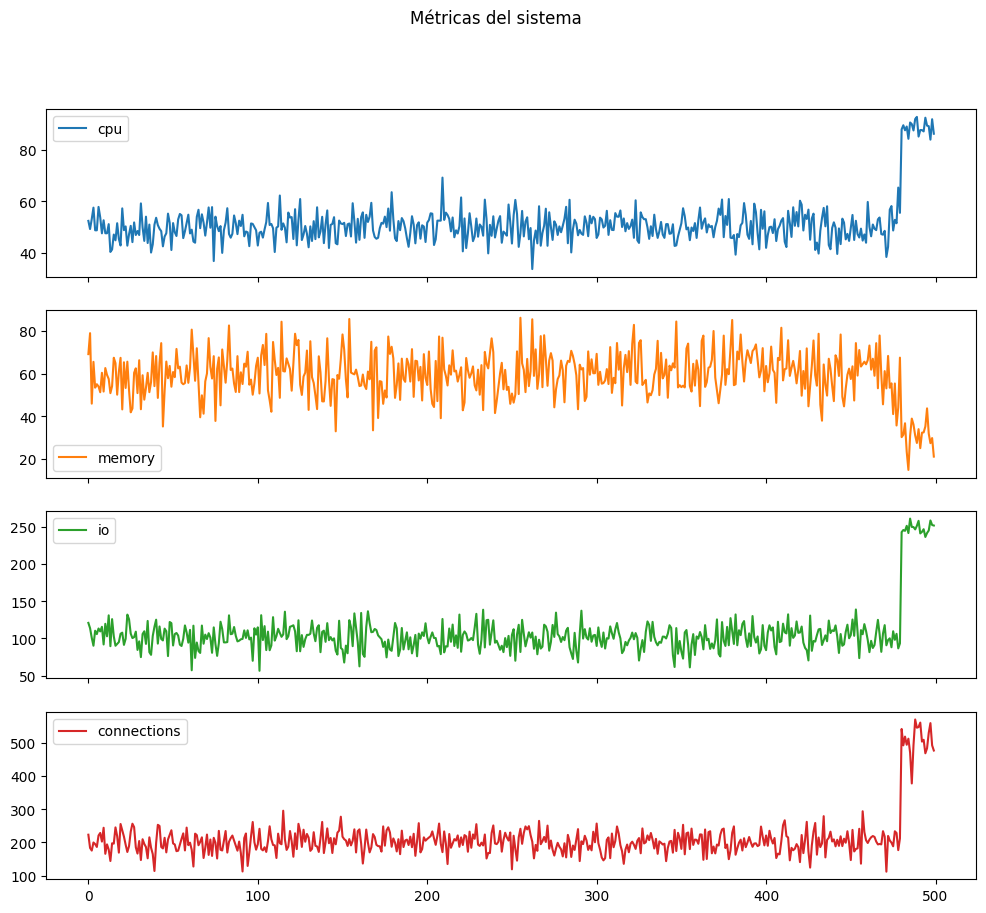

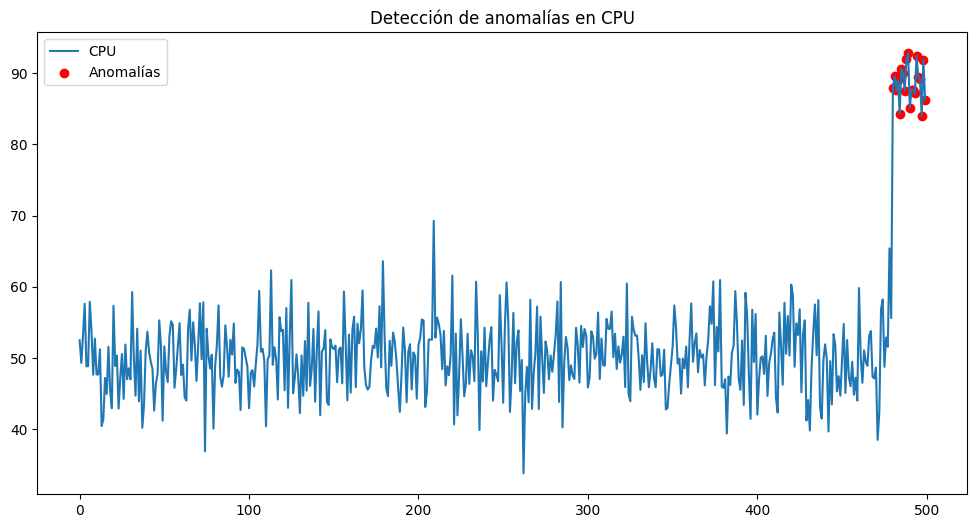

,cpu,memory,io,connections,anomaly
cpu,1.000000,-0.460910,0.735196,0.765113,-0.842978
memory,-0.460910,1.000000,-0.419491,-0.468495,0.513597
io,0.735196,-0.419491,1.000000,0.790615,-0.890463
connections,0.765113,-0.468495,0.790615,1.000000,-0.892959
anomaly,-0.842978,0.513597,-0.890463,-0.892959,1.000000


In [4]:
# 🔍 Detección de anomalías en sistemas (multivariable)

## 📌 Introducción
## 📊 Generación de datos
## 📈 Análisis exploratorio
## 🤖 Modelo de Machine Learning
## 📊 Resultados
## 🧠 Conclusiones

import pandas as pd
import numpy as np

np.random.seed(42)

n = 500

cpu = np.random.normal(50, 5, n)
memory = np.random.normal(60, 10, n)
io = np.random.normal(100, 15, n)
connections = np.random.normal(200, 30, n)

# Insertar anomalías
cpu[480:] = np.random.normal(90, 3, 20)
memory[480:] = np.random.normal(30, 5, 20)
io[480:] = np.random.normal(250, 10, 20)
connections[480:] = np.random.normal(500, 50, 20)

df = pd.DataFrame({
    "cpu": cpu,
    "memory": memory,
    "io": io,
    "connections": connections
})

import matplotlib.pyplot as plt

df.plot(subplots=True, figsize=(12,10), title="Métricas del sistema")
plt.show()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.04, random_state=42)

df["anomaly"] = model.fit_predict(scaled_data)
anomalies = df[df["anomaly"] == -1]
anomalies
plt.figure(figsize=(12,6))
plt.plot(df["cpu"], label="CPU")

plt.scatter(anomalies.index, anomalies["cpu"], color="red", label="Anomalías")

plt.legend()
plt.title("Detección de anomalías en CPU")
plt.show()

df.corr()